In [17]:
import random
from pathlib import Path
from collections import defaultdict
import itertools as it
import os

import pandas as pd
import numpy as np
from supabase import create_client, Client
from dotenv import load_dotenv
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from conjugate_normal import conjugate_normal
load_dotenv()

url = os.getenv('SUPABASE_URL')
key = os.getenv('SUPABASE_KEY')
supabase = create_client(supabase_url=url, supabase_key=key)

In [47]:
response = (
    supabase.table("logs")
    .select("*")
    .gt("created_at", ["2025-06-09 22:44:42.376757+00"])
    .eq("client_name", "cs_gatech_summer_2025")
    .eq("api_endpoint", "/score/summary/stairs")
    .execute()
)
data = response.data

In [48]:
df1 = pd.DataFrame(data)
df2 = pd.json_normalize(df1["request_body"], sep="_")
df3 = pd.json_normalize(df1["response_body"], sep="_")
df = pd.concat([
    df1,
    df2,
    df3
], axis=1)
# Drop columns that start with "focus_time"
df = df.loc[:, ~df.columns.str.startswith('focus_time')]
# Select rows with class_id == "hinze_class"
# df = df.query("class_id == 'hinze_class'")

df = df.dropna(subset=["metrics_content_score"])
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at')
with pd.option_context('display.max_columns', None): 
    display(df)

,id,created_at,api_endpoint,request_method,status_code,client_name,request_body,response_body,ttft,process_time,summary,class_id,page_slug,chat_history,score_history,excluded_chunks,prompt,is_passed,metrics_content_name,metrics_content_score,metrics_content_feedback,metrics_content_is_passed,metrics_content_threshold,metrics_english_name,metrics_english_score,metrics_english_feedback,metrics_english_is_passed,metrics_english_threshold,metrics_profanity_name,metrics_profanity_score,metrics_profanity_feedback,metrics_profanity_is_passed,metrics_profanity_threshold,metrics_similarity_name,metrics_similarity_score,metrics_similarity_feedback,metrics_similarity_is_passed,metrics_similarity_threshold,metrics_containment_name,metrics_containment_score,metrics_containment_feedback,metrics_containment_is_passed,metrics_containment_threshold,metrics_containment_chat_name,metrics_containment_chat_score,metrics_containment_chat_feedback,metrics_containment_chat_is_passed,metrics_containment_chat_threshold,text,chunk,request_id,question_type
10,27816,2025-06-09 23:10:38.367478+00:00,/score/summary/stairs,POST,200,cs_gatech_summer_2025,{'summary': 'A control structure in programmin...,{'prompt': 'Excellent job summarizing the text...,NaN,14.452784,A control structure in programming determines ...,joyner_class,3-1-control-structures,[],[],[The-Dangers-of-Scope-in-Python-2873],Excellent job summarizing the text. Please mov...,True,Content,0.407742,You did a good job of including key ideas and ...,True,0.340979,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.852451,You did a good job of staying on topic and wri...,True,0.5,Language Borrowing,0.0149,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
11,27854,2025-06-09 23:45:00.563189+00:00,/score/summary/stairs,POST,200,cs_gatech_summer_2025,{'summary': 'Conditionals allow a program to m...,{'prompt': 'Excellent job summarizing the text...,NaN,5.545151,Conditionals allow a program to make decisions...,joyner_class,3-2-conditionals,[],[0.407742202281952],"[If-Then-Else-If-Else-2916, Relational-and-Mat...",Excellent job summarizing the text. Please mov...,True,Content,0.318079,You did a good job of including key ideas and ...,True,0.198372,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.889931,You did a good job of staying on topic and wri...,True,0.5,Language Borrowing,0.0000,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
12,27895,2025-06-10 02:17:40.108835+00:00,/score/summary/stairs,POST,200,cs_gatech_summer_2025,"{'summary': 'Primitive types are immutable, an...",{'prompt': 'Excellent job summarizing the text...,NaN,6.831414,"Primitive types are immutable, and their value...",joyner_class,4-1-data-structures,[],"[0.290761560201645, 0.308852046728134, 0.30885...","[Passing-By-Value-An-Analogy-3111, Other-Data-...",Excellent job summarizing the text. Please mov...,True,Content,0.510730,You did a good job of including key ideas and ...,True,0.146461,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.691501,You did a good job of staying on topic and wri...,True,0.5,Language Borrowing,0.1613,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
13,27920,2025-06-10 15:34:47.234088+00:00,/score/summary/stairs,POST,200,cs_gatech_summer_2025,{'summary': 'This page was about control struc...,{'prompt': 'Excellent job summarizing the text...,NaN,5.216353,"This page was about control structures, includ...",joyner_class,3-1-control-structures,[],[],"[What-Do-Control-Structures-Do?-2860, Loops-28...",Excellent job summarizing the text. Please mov...,True,Content,0.486839,You did a good job of including key ideas and ...,True,0.293253,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.859223,You did a good job of staying on topic and wri...,True

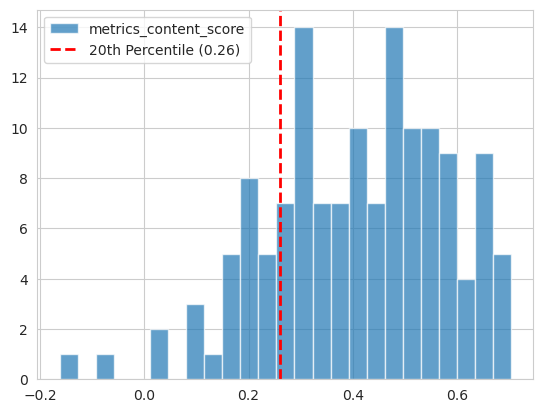

In [49]:
df["metrics_content_score"].hist(legend=True, bins=25, alpha=0.7);

# Calculate and add the 20th percentile line
percentile_20 = df["metrics_content_score"].quantile(0.2)
plt.axvline(percentile_20, color='red', linestyle='--', linewidth=2, label=f"20th Percentile ({percentile_20:.2f})")

# Add legend and show
plt.legend()
plt.show()

In [50]:
df.metrics_content_threshold.mean()

0.20289178094457344

## Simulating the Bayesian Score Distributions

If we had used a Bayesian approach to estimate the scoring distribution over time during these deployments...

In [62]:
mu_global = 0.8
k_global = 1
alpha_global = 4
beta_global = 1

k_volume = 15

In [63]:
volumes = {}
volume_updates = []
submission_threshold = []

volume = conjugate_normal(mu_global, k_global, alpha_global, beta_global, percentile=0.25)
start_threshold = volume.threshold

student_score_history = defaultdict(list)

for i, row in enumerate(df.itertuples()):
    # Create temporary volume prior from volume prior information
    student_dist = conjugate_normal(volume.mu, k_volume, volume.alpha, volume.beta, percentile=0.25)

    # Update temporary volume prior with score history
    score_history = row.score_history
    if score_history:
        student_dist.update(score_history)

    # Record threshold
    submission_threshold.append(student_dist.threshold)

    # volume.update([row.metrics_content_score], increment_k=True)

    # Update Volume
    if not np.isnan(row.metrics_content_score):
        # Update Volume Prior
        if volume.k > 10:
            volume.update([row.metrics_content_score], increment_k=False)
        else:
            volume.update([row.metrics_content_score], increment_k=True)


    volume_updates.append((volume.mu, volume.sigma, volume.threshold))
    
df["bayesian_threshold"] = submission_threshold

,Observed,Simulated Bayesian Personalized,Simulated Bayesian Volume Prior Only,20th Percentile
0,0.93,0.78,0.81,0.78


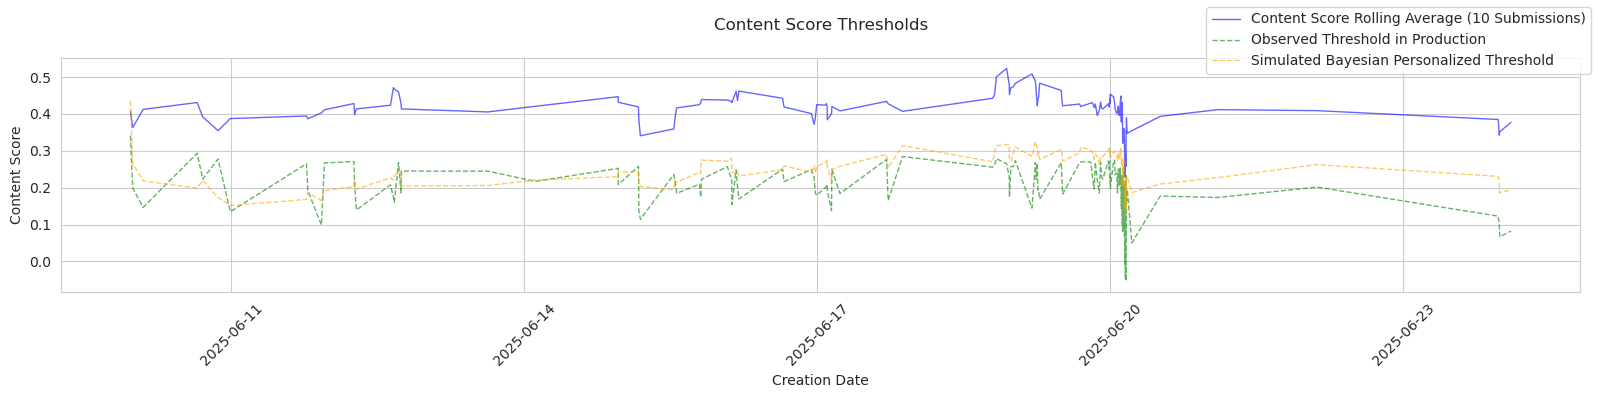

In [64]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, figsize=(16, 4))

pass_rates = []

# Calculate and plot rolling average (10 submissions)
rolling_avg = df['metrics_content_score'].rolling(window=10, min_periods=1).mean()
sns.lineplot(ax=ax, x=df["created_at"], y=rolling_avg, 
             label='Content Score Rolling Average (10 Submissions)', legend=False,
             color='blue', linewidth=1, alpha=0.6)

# Draw Observed Threshold (as the student experienced it)
sns.lineplot(ax=ax, data=df, x='created_at', y='metrics_content_threshold', 
             label='Observed Threshold in Production', legend=False,
             color='green', linewidth=1, alpha=0.6, linestyle='dashed')

# Draw Volume Prior
updates_array = np.array(volume_updates)
# sns.lineplot(ax=ax, x=df['created_at'], y=updates_array[:,2], 
#              label='Simulated Bayesian Volume Prior Threshold', legend=False,
#              color='purple', linewidth=1, alpha=0.6, linestyle='dashed')

# Draw Bayesian Threshold
sns.lineplot(ax=ax, data=df, x='created_at', y='bayesian_threshold', 
             label='Simulated Bayesian Personalized Threshold', legend=False,
             color='orange', linewidth=1, alpha=0.6, linestyle='dashed')

# Manually set the threshold for the first window_size samples
# Since we don't have enough data to calculate a fair rolling averagewindow_size = 10
window_size=10
rolling_20th = df["metrics_content_score"].rolling(window=window_size, min_periods=1, closed='left').quantile(0.2)
rolling_20th.iloc[:window_size] = 0.0

# Print Pass Rates
pass_rates.append({
    "Observed": (df["metrics_content_score"] > df["metrics_content_threshold"]).astype(int).mean(),
    "Simulated Bayesian Personalized": (df["metrics_content_score"] > df["bayesian_threshold"]).astype(int).mean(),
    "Simulated Bayesian Volume Prior Only": (df["metrics_content_score"] > updates_array[:,2]).astype(int).mean(),
    "20th Percentile": (df["metrics_content_score"] > rolling_20th).astype(int).mean(),
})

# Draw Observed 20th Percentile Threshold
# sns.lineplot(
#     ax=ax, data=df, x='created_at', y=rolling_20th,
#     label='20th Percentile (10-Submission Rolling Average)', legend=False,
#     color='red', linewidth=1, alpha=0.6, linestyle='dashed'
# )

# Format x-axis to show only month-year
# plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mpl.dates.DayLocator(interval=3))

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show Pass Rates
display(pd.DataFrame(pass_rates).round(2))

# Add legend
labels_handles = {}
for ax in fig.axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        labels_handles[label] = handle

fig.legend(labels_handles.values(), labels_handles.keys(), loc='upper right', bbox_transform=fig.transFigure, ncol=1)

plt.title('Content Score Thresholds', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')
plt.tight_layout()
    
plt.show();